# Benchmark CH4 Klasik — Rigid Scan (SP), R = 3.00–5.80 Å
### Perbandingan Kurva Energi Potensial (PES) C-H pada CH₄ di Jarak Jauh
**Metode:** HF, B3LYP (DFT), CASSCF(4,4), CASCI approx. (maxiter=1), FCI(10,9) — basis set STO-3G

---
**Catatan metodologi:**
- Scan menggunakan metode **Rigid Scan (Single Point/SP)**: jarak C-H pertama di-scan dari 3.00–5.80 Å, koordinat 3 atom H lainnya difiksasi.
- Geometri menggunakan hasil optimasi Avogadro yang ditranslasikan ke origin:
  `C(0,0,0), H(0,0,R), H(-0.9073,-0.4964,-0.3511), H(0.6732,0.1673,-0.8436), H(-0.2616,0.9589,0.4528)`
- **CASSCF(4,4)** dipakai karena CASSCF(8,8)/STO-3G tidak bisa konvergen untuk CH4 (orbital di luar active space terlalu sempit — hanya 1 orbital tersisa dari total 9 orbital STO-3G).
- **CASCI approx.** menggunakan `maxiter=1` (bukan CASCI murni karena `maxiter=0` menyebabkan I/O error di ORCA 6.0.1).
- **FCI(10,9)** = CASSCF(nel=10, norb=9)/STO-3G → referensi eksak dalam basis STO-3G.
- Di jarak jauh (R > 3.0 Å), ikatan C-H sudah putus → CASSCF/FCI mendekati flat (energi dissociasi).


In [1]:
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Hasil Simulasi (ORCA, Rigid Scan / SP, R = 3.00–5.80 Å)


In [ ]:
import numpy as np

# ── Jarak ikatan C-H (Å) — 16 titik uniform, R = 3.00–5.80 Å ──
R = list(np.linspace(3.00, 5.80, 16))

# ── HF/STO-3G ──
E_HF = [-39.288259310646, -39.274665112793, -39.263829464482, -39.255193542590,
        -39.248271746544, -39.242661000101, -39.238045459732, -39.234177989654,
        -39.230877095157, -39.228008809243, -39.225476606288, -39.223207621148,
        -39.221150189029, -39.219266188635, -39.217528011516, -39.215914482106]

# ── B3LYP/STO-3G ──
E_DFT = [-39.678060017924, -39.670088477999, -39.664084670802, -39.659608573034,
         -39.656293331655, -39.653861268284, -39.652065315506, -39.650698999739,
         -39.649639147140, -39.648812002810, -39.648158215170, -39.647629011206,
         -39.647178349847, -39.646773802601, -39.646402653329, -39.646061342604]

# ── CASSCF(4,4)/STO-3G ──
E_CASSCF = [-37.792991545033, -37.792425712792, -37.792145574076, -37.792010229892,
            -37.791946949480, -37.791917553158, -37.791904556636, -37.791897669843,
            -37.791895283543, -37.791894688837, -37.791894114324, -37.791894542320,
            -37.791894483632, -37.791894450528, -37.791894429707, -37.791894415708]

# ── CASCI approx. (maxiter=1)/STO-3G ──
E_CASCI = [-37.931407410536,
    -37.909240193535,
    -37.892452549768,
    -37.879718258426,
    -37.869979597805,
    -37.862421152258,
    -37.856434500440,
    -37.851577969591,
    -37.847537495995,
    -37.844092865031,
    -37.841090942991,
    -37.838425606376,
    -37.836023222463,
    -37.833832366223,
    -37.831816643673,
    -37.829949747791]

# ── FCI(10,9)/STO-3G (Referensi Eksak) ──
E_FCI = [-39.596270730819, -39.595988753261, -39.595853604291, -39.595790643725,
         -39.595762115794, -39.595749526441, -39.595744113381, -39.595741848976,
         -39.595740929762, -39.595740568706, -39.595740431796, -39.595740381405,
         -39.595740363433, -39.595740357078, -39.595740354888, -39.595740354118]

print(f'Jumlah titik R : {len(R)}')
print(f'Range R        : {R[0]:.2f} – {R[-1]:.2f} Å')
print(f'Step R         : {R[1]-R[0]:.4f} Å')


Jumlah titik R : 16
Range R        : 3.00 – 5.80 Å
Step R         : 0.1867 Å


## 2. Hitung Error Relatif

Referensi: **FCI(10,9)** — energi eksak dalam basis set STO-3G.


In [3]:
# ── Referensi: FCI ──
e_ref        = np.array(E_FCI)
error_hf     = np.abs(np.array(E_HF)     - e_ref)
error_dft    = np.abs(np.array(E_DFT)    - e_ref)
error_casscf = np.abs(np.array(E_CASSCF) - e_ref)
error_casci  = np.abs(np.array(E_CASCI)  - e_ref)

CA = 0.0016  # Chemical Accuracy (Hartree)

print('Error rata-rata vs FCI:')
print(f'  HF     : {np.mean(error_hf):.6e} Ha')
print(f'  B3LYP  : {np.mean(error_dft):.6e} Ha')
print(f'  CASSCF : {np.mean(error_casscf):.6e} Ha')
print(f'  CASCI  : {np.mean(error_casci):.6e} Ha')


Error rata-rata vs FCI:
  HF     : 3.566433e-01 Ha
  B3LYP  : 5.828688e-02 Ha
  CASSCF : 1.803777e+00 Ha
  CASCI  : 5.234436e-01 Ha


## 3. Plot Kurva Energi Potensial (PES) dan Error


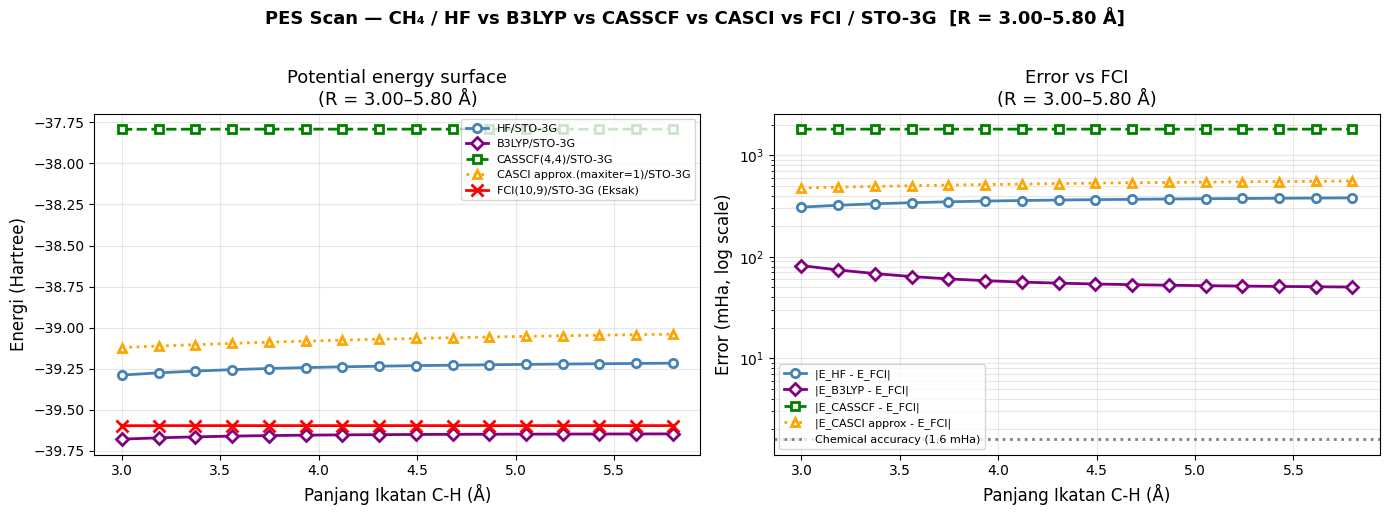

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: PES ──
ax1.plot(R, E_HF,     'o-',  color='steelblue', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(R, E_DFT,    'D-',  color='purple',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(R, E_CASSCF, 's--', color='green',     linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(4,4)/STO-3G')
ax1.plot(R, E_CASCI,  '^:',  color='orange',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI approx.(maxiter=1)/STO-3G')
ax1.plot(R, E_FCI,    'x-',  color='red',       linewidth=2,
         markersize=8, markeredgewidth=2,
         label='FCI(10,9)/STO-3G (Eksak)')

ax1.set_xlabel('Panjang Ikatan C-H (Å)', fontsize=12)
ax1.set_ylabel('Energi (Hartree)', fontsize=12)
ax1.set_title('Potential energy surface\n(R = 3.00–5.80 Å)', fontsize=13)
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3)

# ── Plot 2: Error vs FCI (mHa, log scale) ──
error_hf_mHa     = error_hf     * 1000
error_dft_mHa    = error_dft    * 1000
error_casscf_mHa = error_casscf * 1000
error_casci_mHa  = error_casci  * 1000
CA_mHa = CA * 1000

ax2.semilogy(R, error_hf_mHa     + 1e-7, 'o-',  color='steelblue', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF - E_FCI|')
ax2.semilogy(R, error_dft_mHa    + 1e-7, 'D-',  color='purple',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP - E_FCI|')
ax2.semilogy(R, error_casscf_mHa + 1e-7, 's--', color='green',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASSCF - E_FCI|')
ax2.semilogy(R, error_casci_mHa  + 1e-7, '^:',  color='orange',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI approx - E_FCI|')
ax2.axhline(y=CA_mHa, color='gray', linestyle=':',
            linewidth=2, label='Chemical accuracy (1.6 mHa)')
ax2.set_xlabel('Panjang Ikatan C-H (Å)', fontsize=12)
ax2.set_ylabel('Error (mHa, log scale)', fontsize=12)
ax2.set_title('Error vs FCI\n(R = 3.00–5.80 Å)', fontsize=13)
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.3, which='both')

plt.suptitle('PES Scan — CH₄ / HF vs B3LYP vs CASSCF vs CASCI vs FCI / STO-3G  [R = 3.00–5.80 Å]',
             fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('PES_CH4_SP_3to5.8.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# ── Ringkasan Energi Elektronik ──
print('='*70)
print('RINGKASAN ENERGI CH₄ (STO-3G), R = 3.00–5.80 Å')
print('='*70)
print(f'{"Metode":<22} {"E (R=3.00 Å)":>15} {"E (R=5.80 Å)":>15} {"ΔE (Ha)":>10}')
print('-'*70)
datasets = {
    'HF':            E_HF,
    'B3LYP':         E_DFT,
    'CASSCF(4,4)':   E_CASSCF,
    'CASCI approx.': E_CASCI,
    'FCI(10,9)':     E_FCI,
}
for nama, E in datasets.items():
    delta = abs(E[-1] - E[0])
    print(f'{nama:<22} {E[0]:>15.6f} {E[-1]:>15.6f} {delta:>10.6f}')
print('='*70)
print('\nCatatan: ΔE = |E(5.80) - E(3.00)|')
print('CASSCF/FCI ΔE sangat kecil → sudah flat (bond dissociation terjadi sepenuhnya)')


RINGKASAN ENERGI CH₄ (STO-3G), R = 3.00–5.80 Å
Metode                    E (R=3.00 Å)    E (R=5.80 Å)    ΔE (Ha)
----------------------------------------------------------------------
HF                          -39.288259      -39.215914   0.072345
B3LYP                       -39.678060      -39.646061   0.031999
CASSCF(4,4)                 -37.792992      -37.791894   0.001097
CASCI approx.               -39.120693      -39.039436   0.081257
FCI(10,9)                   -39.596271      -39.595740   0.000530

Catatan: ΔE = |E(5.80) - E(3.00)|
CASSCF/FCI ΔE sangat kecil → sudah flat (bond dissociation terjadi sepenuhnya)
